# Customer Intelligence & Segmentation Platform

## Notebook 04: Customer Segmentation & Cluster Modeling

### Objective

Identify distinct customer segments using behavioral features and unsupervised machine learning.

### Methodology

- Feature Scaling
- Outlier Treatment
- K-Means Clustering
- Elbow Method
- Silhouette Analysis
- PCA Visualization
- Segment Profiling

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

customer_features.head()

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size
0,12346,326,1,77183.60,77183.600000,1,0,74215.000000
1,12347,2,7,4310.00,615.714286,103,365,13.505495
2,12348,75,4,1797.24,449.310000,22,282,75.516129
3,12349,19,1,1757.55,1757.550000,73,0,8.643836
4,12350,310,1,334.40,334.400000,17,0,11.588235


In [3]:
print(customer_features.shape)

customer_features.info()

(4338, 8)
<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   int64  
 1   Recency            4338 non-null   int64  
 2   Frequency          4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   Avg_Order_Value    4338 non-null   float64
 5   Product_Diversity  4338 non-null   int64  
 6   Tenure             4338 non-null   int64  
 7   Avg_Basket_Size    4338 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 271.3 KB


In [4]:
X = customer_features.drop(
    columns=["CustomerID"]
)

X.head()

,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size
0,326,1,77183.60,77183.600000,1,0,74215.000000
1,2,7,4310.00,615.714286,103,365,13.505495
2,75,4,1797.24,449.310000,22,282,75.516129
3,19,1,1757.55,1757.550000,73,0,8.643836
4,310,1,334.40,334.400000,17,0,11.588235


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 2.33457414e+00, -4.25096503e-01,  8.36301037e+00, ...,
        -7.08801901e-01, -9.88064772e-01,  6.16387972e+01],
       [-9.05340320e-01,  3.54416797e-01,  2.51698905e-01, ...,
         4.86180191e-01,  1.77657708e+00, -2.62404421e-02],
       [-1.75359593e-01, -3.53398530e-02, -2.79878269e-02, ...,
        -4.62776177e-01,  1.14790510e+00,  2.52934002e-02],
       ...,
       [-8.45341904e-01, -2.95177619e-01, -2.08214334e-01, ...,
        -5.79931284e-01, -9.42901465e-02, -3.03309965e-02],
       [-8.85340848e-01,  1.52368675e+00, -3.51515172e-04, ...,
         2.36066191e+00,  1.53419752e+00, -3.59000393e-02],
       [-4.95351144e-01, -1.65258736e-01, -2.35311112e-02, ...,
        -2.93022801e-02,  2.08684303e-01, -1.86349788e-02]])

In [6]:
inertia = []

k_range = range(2,11)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

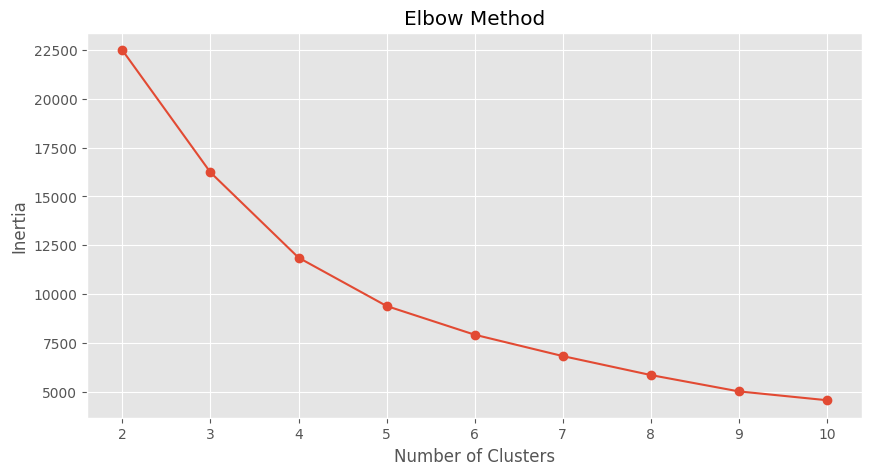

In [7]:
plt.figure(figsize=(10,5))

plt.plot(
    k_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [8]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

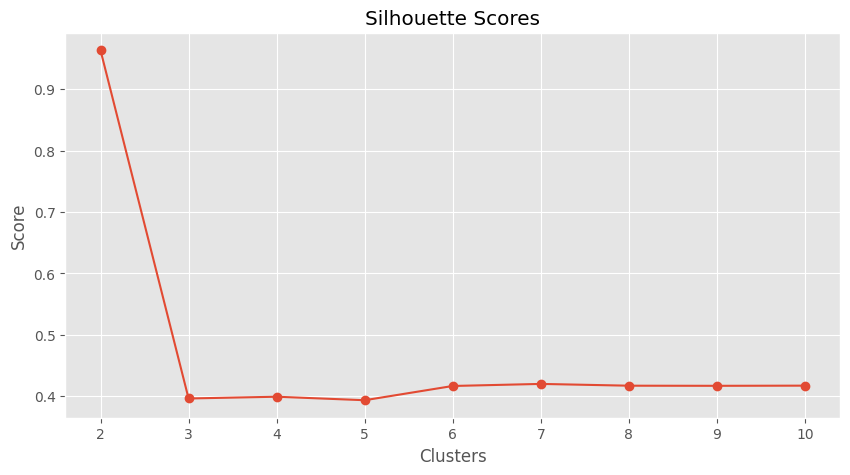

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.title("Silhouette Scores")

plt.xlabel("Clusters")

plt.ylabel("Score")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_features["Cluster"] = (
    kmeans.fit_predict(X_scaled)
)

customer_features.head()

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size,Cluster
0,12346,326,1,77183.60,77183.600000,1,0,74215.000000,2
1,12347,2,7,4310.00,615.714286,103,365,13.505495,0
2,12348,75,4,1797.24,449.310000,22,282,75.516129,0
3,12349,19,1,1757.55,1757.550000,73,0,8.643836,3
4,12350,310,1,334.40,334.400000,17,0,11.588235,1


In [11]:
customer_features["Cluster"].value_counts()

Cluster
3    1871
0    1470
1     979
4      16
2       2
Name: count, dtype: int64

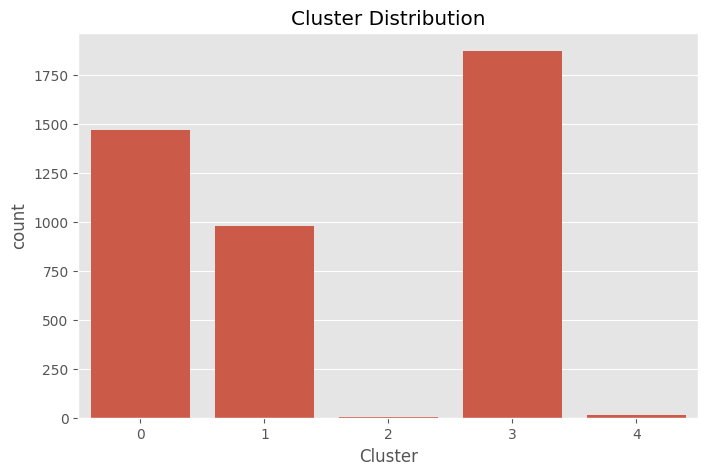

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_features,
    x="Cluster"
)

plt.title("Cluster Distribution")

plt.show()

In [13]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = (
    customer_features["Cluster"]
)

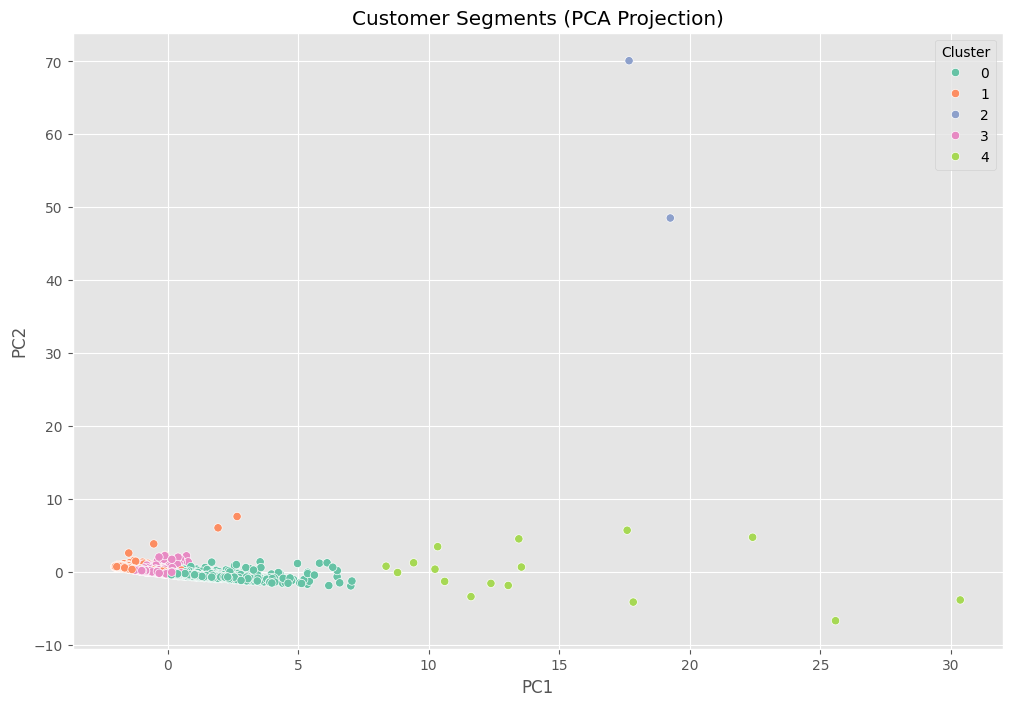

In [14]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments (PCA Projection)")

plt.show()

In [15]:
cluster_profile = (
    customer_features
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size
Cluster,,,,,,,,
0,15300.60,28.88,8.05,3434.11,407.74,111.36,288.53,17.18
1,15342.58,256.71,1.50,538.48,338.70,23.21,20.62,26.15
2,14396.00,163.50,1.50,122828.05,80709.92,2.00,102.00,50607.00
3,15281.24,57.30,2.11,741.56,366.52,36.59,61.92,22.69
4,15056.44,7.00,79.69,104923.68,2099.95,743.62,343.81,65.24


In [16]:
cluster_profile

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size
Cluster,,,,,,,,
0,15300.60,28.88,8.05,3434.11,407.74,111.36,288.53,17.18
1,15342.58,256.71,1.50,538.48,338.70,23.21,20.62,26.15
2,14396.00,163.50,1.50,122828.05,80709.92,2.00,102.00,50607.00
3,15281.24,57.30,2.11,741.56,366.52,36.59,61.92,22.69
4,15056.44,7.00,79.69,104923.68,2099.95,743.62,343.81,65.24


In [17]:
segment_map = {
    0: "Loyal Customers",
    1: "Dormant Customers",
    2: "Wholesale Buyers",
    3: "Potential Loyalists",
    4: "VIP Customers"
}

customer_features["Segment"] = (
    customer_features["Cluster"]
    .map(segment_map)
)

In [18]:
customer_features["Segment"].value_counts()

Segment
Potential Loyalists    1871
Loyal Customers        1470
Dormant Customers       979
VIP Customers            16
Wholesale Buyers          2
Name: count, dtype: int64

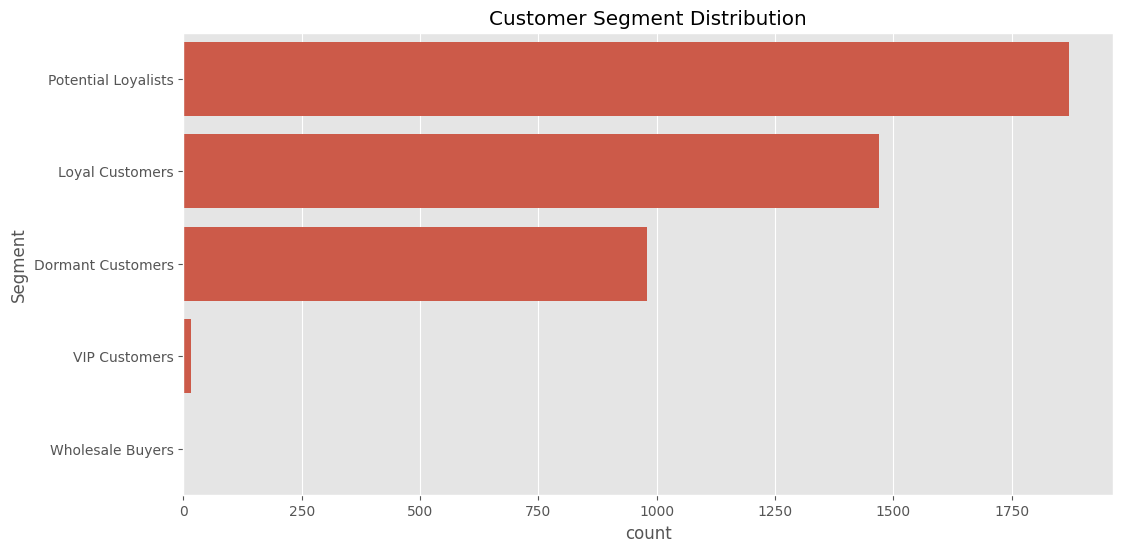

In [19]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=customer_features,
    y="Segment",
    order=customer_features["Segment"]
            .value_counts()
            .index
)

plt.title("Customer Segment Distribution")

plt.show()

In [20]:
segment_revenue = (
    customer_features
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Loyal Customers        5048145.101
VIP Customers          1678778.830
Potential Loyalists    1387461.092
Dormant Customers       527167.771
Wholesale Buyers        245656.100
Name: Monetary, dtype: float64

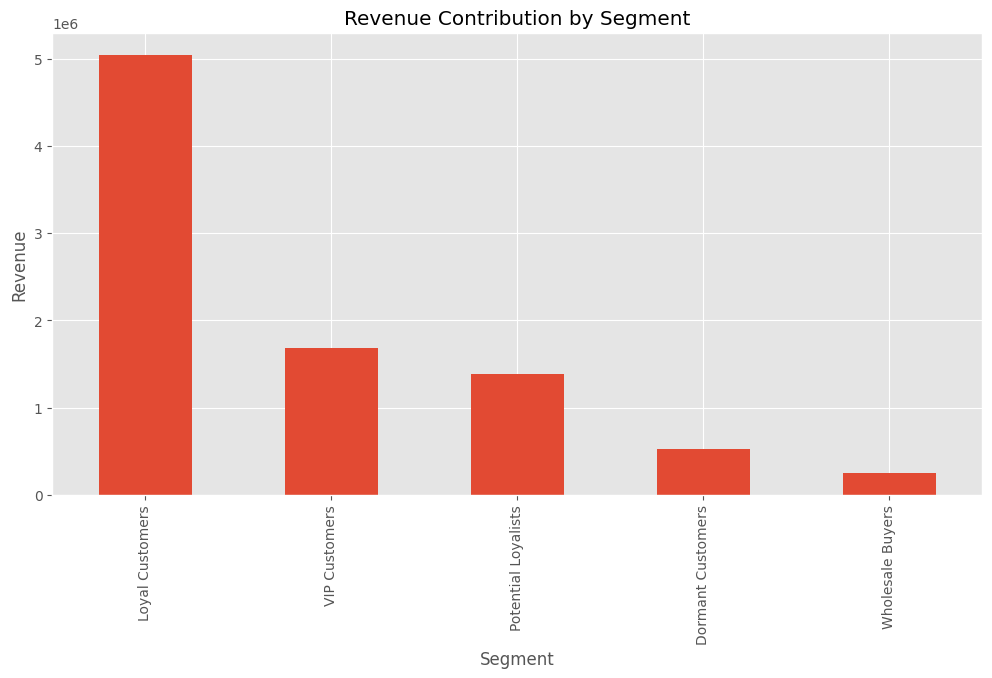

In [21]:
plt.figure(figsize=(12,6))

segment_revenue.plot(
    kind="bar"
)

plt.title("Revenue Contribution by Segment")

plt.ylabel("Revenue")

plt.show()

In [22]:
segment_profile = (
    customer_features
    .groupby("Segment")
    .agg({
        "Recency":"mean",
        "Frequency":"mean",
        "Monetary":"mean",
        "Product_Diversity":"mean",
        "Tenure":"mean"
    })
    .round(2)
)

segment_profile

,Recency,Frequency,Monetary,Product_Diversity,Tenure
Segment,,,,,
Dormant Customers,256.71,1.50,538.48,23.21,20.62
Loyal Customers,28.88,8.05,3434.11,111.36,288.53
Potential Loyalists,57.30,2.11,741.56,36.59,61.92
VIP Customers,7.00,79.69,104923.68,743.62,343.81
Wholesale Buyers,163.50,1.50,122828.05,2.00,102.00


In [23]:
customer_features.to_csv(
    "../data/processed/segmented_customers.csv",
    index=False
)

print(
    "segmented_customers.csv saved successfully"
)

segmented_customers.csv saved successfully


In [24]:
import joblib

joblib.dump(
    kmeans,
    "../outputs/models/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "../outputs/models/scaler.pkl"
)

print("Models Saved")

Models Saved
